In [1]:
import numpy as np

train = np.load('synthetic_embeddings.npz', allow_pickle=True)
val   = np.load('human_embeddings.npz', allow_pickle=True)

print(train.files)  # see what keys are in there
print(train['embeddings'].shape)  # e.g. (2000, 768)
print(train['labels'].shape)     # e.g. (2000, 4)  -- R1, R2, R3, C1

['embeddings', 'labels', 'ids']
(2000, 768)
(2000, 4)


In [3]:
import pandas as pd
import re

def compute_manual_features(utterance_text):
    """Returns a feature vector for one utterance."""
    text = utterance_text.lower()
    return {
        'word_count': len(text.split()),
        'char_count': len(text),
        'question_mark': int('?' in text),
        'contains_why': int('why' in text.split()),
        'contains_how': int('how' in text.split()),
        'contains_what': int('what' in text.split()),
        'contains_because': int('because' in text),
        'contains_tell_me_more': int('tell me more' in text),
        'contains_can_you_explain': int('can you explain' in text),
        'exclamation': int('!' in text),
        'ellipsis': int('...' in text),
        'first_person_i': int(bool(re.search(r'\bi\b', text))),
        'second_person_you': int(bool(re.search(r'\byou\b', text))),
        'avg_word_length': sum(len(w) for w in text.split()) / max(1, len(text.split())),
    }

# Apply over the utterances dataframe
df['manual_features'] = df['utterance'].apply(compute_manual_features)
manual_feature_matrix = pd.DataFrame(df['manual_features'].tolist()).values

NameError: name 'df' is not defined

In [4]:
import os
import glob

# See all CSVs in your project
for f in glob.glob('**/*.csv', recursive=True):
    print(f)

ncte_single_utterances.csv
chatgpt_annotations.csv
Utterances for chatgpt.csv
paired_annotations.csv
agreed_annotations.csv
edu/lib/python3.11/site-packages/numpy/core/tests/data/umath-validation-set-log2.csv
edu/lib/python3.11/site-packages/numpy/core/tests/data/umath-validation-set-arcsinh.csv
edu/lib/python3.11/site-packages/numpy/core/tests/data/umath-validation-set-arctanh.csv
edu/lib/python3.11/site-packages/numpy/core/tests/data/umath-validation-set-sin.csv
edu/lib/python3.11/site-packages/numpy/core/tests/data/umath-validation-set-cos.csv
edu/lib/python3.11/site-packages/numpy/core/tests/data/umath-validation-set-cbrt.csv
edu/lib/python3.11/site-packages/numpy/core/tests/data/umath-validation-set-arctan.csv
edu/lib/python3.11/site-packages/numpy/core/tests/data/umath-validation-set-cosh.csv
edu/lib/python3.11/site-packages/numpy/core/tests/data/umath-validation-set-expm1.csv
edu/lib/python3.11/site-packages/numpy/core/tests/data/umath-validation-set-sinh.csv
edu/lib/python3.11/

In [6]:
import pandas as pd

# Try these one by one — whichever exists
df = pd.read_csv('NCTE_Transcripts/ncte_single_utterances.csv')
print(df.columns.tolist())
print(df.head(2))

FileNotFoundError: [Errno 2] No such file or directory: 'NCTE_Transcripts/ncte_single_utterances.csv'

In [7]:
import pandas as pd
import numpy as np

# Check the cleaned utterances file
utt_df = pd.read_csv('NCTE_Transcripts/processed/ncte_single_utterances_cleaned.csv')
print("=== ncte_single_utterances_cleaned.csv ===")
print(utt_df.columns.tolist())
print(utt_df.head(2))
print(utt_df.shape)

=== ncte_single_utterances_cleaned.csv ===
['speaker', 'text', 'year', 'OBSID', 'video_id', 'cleaned_text', 'num_words', 'turn_idx', 'comb_idx', 'cleaned_text_v2', 'num_words_v2', 'is_teacher', 'is_student', 'prev_speaker', 'prev_text', 'teacher_after_student', 'student_after_teacher', 'teacher_acknowledgment', 'teacher_reformulation_overlap', 'teacher_question', 'student_after_question']
   speaker                                               text  year  OBSID  \
0  teacher  Okay.  Math should be out.  Everything else, p...     1      3   
1  student                                                 C.     1      3   

   video_id                                       cleaned_text  num_words  \
0       329  okay math should be out everything else please...        197   
1       329                                                  c          1   

   turn_idx comb_idx                                    cleaned_text_v2  ...  \
0         0      3_0  okay math should be out everything else

In [8]:
# Check chatgpt_annotations.csv — this is likely the training set (n=2000 pseudo-labels)
chat_df = pd.read_csv('chatgpt_annotations.csv')
print("=== chatgpt_annotations.csv ===")
print(chat_df.columns.tolist())
print(chat_df.head(2))
print(chat_df.shape)

=== chatgpt_annotations.csv ===
['target_comb_idx', 'R1_chatgpt', 'R2_chatgpt', 'R3_chatgpt', 'C1_chatgpt']
  target_comb_idx  R1_chatgpt  R2_chatgpt  R3_chatgpt  C1_chatgpt
0           10_31           0           0           0           0
1         113_415           0           0           0           1
(116, 5)


In [9]:
# Check agreed_annotations.csv — this is likely the validation set (human labels)
agreed_df = pd.read_csv('agreed_annotations.csv')
print("=== agreed_annotations.csv ===")
print(agreed_df.columns.tolist())
print(agreed_df.head(2))
print(agreed_df.shape)

=== agreed_annotations.csv ===
['target_comb_idx', 'target_text', 'ctx_-4_speaker', 'ctx_-4_text', 'ctx_-3_speaker', 'ctx_-3_text', 'ctx_-2_speaker', 'ctx_-2_text', 'ctx_-1_speaker', 'ctx_-1_text', 'ctx_0_speaker', 'ctx_0_text', 'ctx_1_speaker', 'ctx_1_text', 'ctx_2_speaker', 'ctx_2_text', 'R1: References prior student content_final', 'R2: Builds on student content_final', 'R3: Invites further student thinking_final', 'C1. No student content available (N/A)_final', 'C2. Want annotation review_final']
  target_comb_idx                                        target_text  \
0           10_31  You may go get it. Student A, can you please g...   
1         113_415                                    Boys, let’s go.   

  ctx_-4_speaker                                        ctx_-4_text  \
0        teacher  9’s? Okay. Alright. Everyone’s quiz should be ...   
1        teacher  You’re really lucky this didn’t fall off.  I s...   

  ctx_-3_speaker                                        ctx_-3_

In [10]:
# Also check what the IDs in your npz files look like so we can match them
train_data = np.load('synthetic_embeddings.npz', allow_pickle=True)
val_data   = np.load('human_embeddings.npz', allow_pickle=True)
print("Train IDs sample:", train_data['ids'][:5])
print("Val IDs sample:  ", val_data['ids'][:5])

Train IDs sample: ['912_156' '230_49' '2262_108' '38_177' '2981_265']
Val IDs sample:   ['10_31' '113_415' '11_450' '130_4' '15_153']


In [11]:
import pandas as pd

chat_df = pd.read_csv('chatgpt_annotations.csv')
print("=== chatgpt_annotations.csv ===")
print(chat_df.columns.tolist())
print(chat_df.shape)
print(chat_df.head(2))

=== chatgpt_annotations.csv ===
['target_comb_idx', 'R1_chatgpt', 'R2_chatgpt', 'R3_chatgpt', 'C1_chatgpt']
(116, 5)
  target_comb_idx  R1_chatgpt  R2_chatgpt  R3_chatgpt  C1_chatgpt
0           10_31           0           0           0           0
1         113_415           0           0           0           1


In [12]:
agreed_df = pd.read_csv('agreed_annotations.csv')
print("=== agreed_annotations.csv ===")
print(agreed_df.columns.tolist())
print(agreed_df.shape)
print(agreed_df.head(2))

=== agreed_annotations.csv ===
['target_comb_idx', 'target_text', 'ctx_-4_speaker', 'ctx_-4_text', 'ctx_-3_speaker', 'ctx_-3_text', 'ctx_-2_speaker', 'ctx_-2_text', 'ctx_-1_speaker', 'ctx_-1_text', 'ctx_0_speaker', 'ctx_0_text', 'ctx_1_speaker', 'ctx_1_text', 'ctx_2_speaker', 'ctx_2_text', 'R1: References prior student content_final', 'R2: Builds on student content_final', 'R3: Invites further student thinking_final', 'C1. No student content available (N/A)_final', 'C2. Want annotation review_final']
(116, 21)
  target_comb_idx                                        target_text  \
0           10_31  You may go get it. Student A, can you please g...   
1         113_415                                    Boys, let’s go.   

  ctx_-4_speaker                                        ctx_-4_text  \
0        teacher  9’s? Okay. Alright. Everyone’s quiz should be ...   
1        teacher  You’re really lucky this didn’t fall off.  I s...   

  ctx_-3_speaker                                     

In [19]:
import pandas as pd
import numpy as np

# ── 1. Load npz files ──────────────────────────────────────────────────
train_data = np.load('synthetic_embeddings.npz', allow_pickle=True)
val_data   = np.load('human_embeddings.npz',     allow_pickle=True)

train_embeddings = train_data['embeddings']
val_embeddings   = val_data['embeddings']
train_ids        = train_data['ids']
val_ids          = val_data['ids']
train_labels     = train_data['labels']
val_labels       = val_data['labels']

print("Train shape:", train_embeddings.shape, "| Val shape:", val_embeddings.shape)
print("Train labels shape:", train_labels.shape, "| Val labels shape:", val_labels.shape)

# ── 2. Build universal text lookup from big utterances file ────────────
utt_df = pd.read_csv('NCTE_Transcripts/processed/ncte_single_utterances_cleaned.csv')
utt_df['lookup_id'] = utt_df['video_id'].astype(str) + '_' + utt_df['turn_idx'].astype(str)
utt_lookup = utt_df.drop_duplicates(subset='lookup_id').set_index('lookup_id')['cleaned_text_v2']

# ── 3. Look up texts for train and val ────────────────────────────────
train_texts = utt_lookup.reindex(train_ids).values
val_texts   = utt_lookup.reindex(val_ids).values

print("Train missing:", sum(pd.isnull(train_texts)), "/ ", len(train_texts))
print("Val missing:  ", sum(pd.isnull(val_texts)),   "/ ", len(val_texts))
print("Train sample:", train_texts[:2])
print("Val sample:  ", val_texts[:2])

Train shape: (2000, 768) | Val shape: (200, 768)
Train labels shape: (2000, 4) | Val labels shape: (200, 4)
Train missing: 1759 /  2000
Val missing:   178 /  200
Train sample: <StringArray>
[nan, nan]
Length: 2, dtype: str
Val sample:   <StringArray>
[nan, nan]
Length: 2, dtype: str


In [20]:
# Check what the npz IDs look like vs what we're building
print("NPZ train IDs sample:", train_ids[:5])
print("NPZ val IDs sample:  ", val_ids[:5])

# Check the actual columns in utt_df
print("\nutt_df sample:")
print(utt_df[['video_id', 'OBSID', 'turn_idx', 'comb_idx']].head(10))

# Try building lookup with OBSID instead of video_id
utt_df['lookup_id_obsid'] = utt_df['OBSID'].astype(str) + '_' + utt_df['turn_idx'].astype(str)

# See if any npz IDs match either format
sample = train_ids[:10]
vid_matches   = utt_df['lookup_id'].isin(sample).sum()
obsid_matches = utt_df['lookup_id_obsid'].isin(sample).sum()
comb_matches  = utt_df['comb_idx'].isin(sample).sum()

print("\nMatches using video_id_turn_idx:", vid_matches)
print("Matches using OBSID_turn_idx:   ", obsid_matches)
print("Matches using comb_idx:         ", comb_matches)

NPZ train IDs sample: ['912_156' '230_49' '2262_108' '38_177' '2981_265']
NPZ val IDs sample:   ['10_31' '113_415' '11_450' '130_4' '15_153']

utt_df sample:
   video_id  OBSID  turn_idx comb_idx
0       329      3         0      3_0
1       329      3         1      3_1
2       329      3         2      3_2
3       329      3         3      3_3
4       329      3         4      3_4
5       329      3         5      3_5
6       329      3         6      3_6
7       329      3         7      3_7
8       329      3         8      3_8
9       329      3         9      3_9

Matches using video_id_turn_idx: 7
Matches using OBSID_turn_idx:    10
Matches using comb_idx:          10


In [21]:
# Use comb_idx as the lookup key
utt_lookup = utt_df.drop_duplicates(subset='comb_idx').set_index('comb_idx')['cleaned_text_v2']

train_texts = utt_lookup.reindex(train_ids).values
val_texts   = utt_lookup.reindex(val_ids).values

print("Train missing:", sum(pd.isnull(train_texts)), "/", len(train_texts))
print("Val missing:  ", sum(pd.isnull(val_texts)),   "/", len(val_texts))
print("Train sample:", train_texts[:3])
print("Val sample:  ", val_texts[:3])

Train missing: 9 / 2000
Val missing:   0 / 200
Train sample: <StringArray>
[                                                                                                                                                                                                                                                                                                                     'well i don t have three rooms but i do kind of use three rooms i guess you can think of it as that and here they are we're gonna have to move chairs up thank you and we have some kits and in here we have go through and push your chair up and out of the way obviously there s something going on in here huh back when i moved them they didn t have anything going on in here now what you re gonna need to do is give everybody a kit okay',
                                                                                                                                                                                  

In [22]:
### Task 5:
import re
from sklearn.preprocessing import StandardScaler

def compute_manual_features(text):
    if pd.isnull(text):
        text = ''
    text_lower = text.lower()
    words = text_lower.split()
    return [
        len(words),
        len(text),
        int('?' in text),
        int('!' in text),
        int('why'     in words),
        int('how'     in words),
        int('what'    in words),
        int('because' in text_lower),
        int('tell me more'      in text_lower),
        int('can you explain'   in text_lower),
        int('what do you think' in text_lower),
        int('...' in text),
        int(bool(re.search(r'\bi\b',  text_lower))),
        int(bool(re.search(r'\byou\b', text_lower))),
        int(bool(re.search(r'\bwe\b',  text_lower))),
        sum(len(w) for w in words) / max(1, len(words)),
        len(set(words)) / max(1, len(words)),
    ]

train_manual = np.array([compute_manual_features(t) for t in train_texts])
val_manual   = np.array([compute_manual_features(t) for t in val_texts])

scaler = StandardScaler()
train_manual_scaled = scaler.fit_transform(train_manual)
val_manual_scaled   = scaler.transform(val_manual)

X_train = np.concatenate([train_embeddings, train_manual_scaled], axis=1)
X_val   = np.concatenate([val_embeddings,   val_manual_scaled],   axis=1)

y_train = train_labels
y_val   = val_labels

print("X_train:", X_train.shape)  # (2000, 785)
print("X_val:  ", X_val.shape)    # (200, 785)
print("y_train:", y_train.shape)  # (2000, 4)
print("y_val:  ", y_val.shape)    # (200, 4)

X_train: (2000, 785)
X_val:   (200, 785)
y_train: (2000, 4)
y_val:   (200, 4)


In [30]:
### Taks 6:
### Task 6:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import cohen_kappa_score, f1_score
import warnings
warnings.filterwarnings('ignore')

label_names = ['R1', 'R2', 'R3', 'C1']
results = []

classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVM':                SVC(kernel='rbf'),
    'MLP':                MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42),
}

for clf_name, clf in classifiers.items():
    print(f"\nTraining {clf_name}...")
    for i, label in enumerate(label_names):
        clf.fit(X_train, y_train[:, i])
        preds = clf.predict(X_val)
        kappa = cohen_kappa_score(y_val[:, i], preds)
        f1 = f1_score(y_val[:, i], preds)
        results.append({'Classifier': clf_name, 'Label': label, 'Kappa': round(kappa, 4), 'F1': round(f1, 4)})
        print(f"  {label}: F1 = {f1:.4f}  kappa = {kappa:.4f}")

results_df = pd.DataFrame(results)
print("\n=== F1 Results Table ===")
print(results_df.pivot(index='Classifier', columns='Label', values='F1').to_string())
print("\n=== Kappa Results Table ===")
print(results_df.pivot(index='Classifier', columns='Label', values='Kappa').to_string())


Training LogisticRegression...
  R1: F1 = 0.4500  kappa = 0.2202
  R2: F1 = 0.3390  kappa = 0.2691
  R3: F1 = 0.7526  kappa = 0.5331
  C1: F1 = 0.1429  kappa = 0.1011

Training SVM...
  R1: F1 = 0.0000  kappa = 0.0000
  R2: F1 = 0.0000  kappa = 0.0000
  R3: F1 = 0.6875  kappa = 0.4792
  C1: F1 = 0.0000  kappa = 0.0000

Training MLP...
  R1: F1 = 0.6133  kappa = 0.3846
  R2: F1 = 0.4337  kappa = 0.2887
  R3: F1 = 0.7128  kappa = 0.4685
  C1: F1 = 0.1429  kappa = 0.1011

=== F1 Results Table ===
Label                   C1      R1      R2      R3
Classifier                                        
LogisticRegression  0.1429  0.4500  0.3390  0.7526
MLP                 0.1429  0.6133  0.4337  0.7128
SVM                 0.0000  0.0000  0.0000  0.6875

=== Kappa Results Table ===
Label                   C1      R1      R2      R3
Classifier                                        
LogisticRegression  0.1011  0.2202  0.2691  0.5331
MLP                 0.1011  0.3846  0.2887  0.4685
SVM         

In [31]:
### Task 7:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import cohen_kappa_score, f1_score, make_scorer

f1_scorer = make_scorer(f1_score)

# ── Tune MLP for R1, R2, C1 (where MLP was best or tied) ─────────────
mlp_param_grid = {
    'hidden_layer_sizes': [(128,), (256, 128), (512, 256)],
    'alpha':              [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 5e-4],
}

# ── Tune LR for R3 (where LR was best) ───────────────────────────────
lr_param_grid = {
    'C':       [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear'],
}

tuning_plan = {
    'R1': ('MLP', MLPClassifier(max_iter=500, random_state=42), mlp_param_grid),
    'R2': ('MLP', MLPClassifier(max_iter=500, random_state=42), mlp_param_grid),
    'R3': ('LR',  LogisticRegression(max_iter=1000),            lr_param_grid),
    'C1': ('MLP', MLPClassifier(max_iter=500, random_state=42), mlp_param_grid),
}

tuned_results = []

for label, (clf_name, clf, grid) in tuning_plan.items():
    i = label_names.index(label)
    print(f"Tuning {clf_name} for {label}...")
    search = GridSearchCV(clf, grid, scoring=f1_scorer, cv=3, n_jobs=-1)
    search.fit(X_train, y_train[:, i])
    best_preds = search.best_estimator_.predict(X_val)
    kappa = cohen_kappa_score(y_val[:, i], best_preds)
    f1 = f1_score(y_val[:, i], best_preds)
    tuned_results.append({
        'Label': label, 'Classifier': clf_name,
        'Best Params': search.best_params_,
        'Kappa': round(kappa, 4),
        'F1': round(f1, 4)
    })
    print(f"  Best params: {search.best_params_}")
    print(f"  F1:    {f1:.4f}")
    print(f"  Kappa: {kappa:.4f}")

print("\n=== Tuned Results ===")
for r in tuned_results:
    print(f"{r['Label']} ({r['Classifier']}): F1={r['F1']}  kappa={r['Kappa']}  params={r['Best Params']}")

Tuning MLP for R1...
  Best params: {'alpha': 0.001, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001}
  F1:    0.5417
  Kappa: 0.2851
Tuning MLP for R2...
  Best params: {'alpha': 0.01, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001}
  F1:    0.5618
  Kappa: 0.4369
Tuning LR for R3...
  Best params: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
  F1:    0.7526
  Kappa: 0.5331
Tuning MLP for C1...
  Best params: {'alpha': 0.01, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.0005}
  F1:    0.1159
  Kappa: 0.0813

=== Tuned Results ===
R1 (MLP): F1=0.5417  kappa=0.2851  params={'alpha': 0.001, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001}
R2 (MLP): F1=0.5618  kappa=0.4369  params={'alpha': 0.01, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001}
R3 (LR): F1=0.7526  kappa=0.5331  params={'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
C1 (MLP): F1=0.1159  kappa=0.0813  params={'alpha': 0.01, 'hidden_layer_sizes': (128,), 'learning_rat

In [25]:
import joblib
import os
os.makedirs('outputs/models', exist_ok=True)

# Re-train the final best model for each label with best settings
final_models = {
    'R1': MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42),  # baseline MLP
    'R2': MLPClassifier(hidden_layer_sizes=(128,), alpha=0.01, learning_rate_init=0.001, max_iter=500, random_state=42),  # tuned MLP
    'R3': LogisticRegression(C=1.0, penalty='l2', solver='liblinear', max_iter=1000),   # tuned LR
    'C1': LogisticRegression(max_iter=1000),                                             # baseline LR
}

final_kappas = {}
for label, model in final_models.items():
    i = label_names.index(label)
    model.fit(X_train, y_train[:, i])
    preds = model.predict(X_val)
    kappa = cohen_kappa_score(y_val[:, i], preds)
    final_kappas[label] = round(kappa, 4)
    joblib.dump(model, f'outputs/models/best_{label}.pkl')
    print(f"{label}: kappa={kappa:.4f} — saved")

print("\nFinal best kappas:", final_kappas)

R1: kappa=0.3846 — saved
R2: kappa=0.4369 — saved
R3: kappa=0.5331 — saved
C1: kappa=0.1011 — saved

Final best kappas: {'R1': 0.3846, 'R2': 0.4369, 'R3': 0.5331, 'C1': 0.1011}


In [27]:
### Analysis?
import pandas as pd
import numpy as np
import joblib

# Load the full utterances — teacher utterances only (responsiveness only applies to teachers)
utt_df = pd.read_csv('NCTE_Transcripts/processed/ncte_single_utterances_cleaned.csv')
teacher_df = utt_df[utt_df['is_teacher'] == True].copy()
print("Total teacher utterances:", len(teacher_df))

# Also load metadata for joining later
meta_df = pd.read_csv('NCTE_Transcripts/processed/transcript_metadata.csv', encoding='latin-1')
print("Metadata columns:", meta_df.columns.tolist())
print(meta_df.head(2))

Total teacher utterances: 286561
Metadata columns: ['OBSID', 'year', 'student_text', 'teacher_text', 'student_cleaned', 'teacher_cleaned', 'NCTETID', 'DISTRICT', 'CLASS_11', 'CLASS_12', 'CLASS_13', 'SCHOOLYEAR_SP', 'RATERID', 'OBSYEAR', 'OBSMONTH', 'OBSDAY', 'CHAPNUM', 'CLPC', 'CLNC', 'CLTS', 'CLRSP', 'CLBM', 'CLPRDT', 'CLILF', 'CLCU', 'CLAPS', 'CLQF', 'CLINSTD', 'CLSTENG', 'MQI_11', 'MQI_12', 'MQI_13', 'FORMAT_ACTIVE', 'FORMAT_BOTH', 'FORMAT_SMALLGRP', 'DIRINST', 'APLPROB', 'CWCM', 'WCDISS', 'LINK', 'EXPL', 'MMETH', 'MGEN', 'MLANG', 'ORICH', 'ORICH4', 'REMED', 'USEPROD', 'MATCON', 'OWWS', 'OWWS4', 'MAJERR', 'LANGIMP', 'LCP', 'OERR', 'OERR4', 'STEXPL', 'SMQR', 'ETCA', 'OSPMMR', 'OSPMMR4', 'STUCON', 'STUCOM', 'SMALDIS', 'MMSM', 'ORIENT', 'SUMM', 'MQI_CHECK', 'DIFFINST', 'LLC', 'MQI3', 'MKT3', 'MQI5', 'MKT5', 'TSTUDEA', 'TREMSTU', 'STUENG', 'CLMATINQ', 'LESSEFFIC', 'DENSMAT', 'LATASK', 'LESSCLEAR', 'TASKDEVMAT', 'ERRANN', 'WORLD', 'SCHOOLID', 'STATEVA_M', 'STATEVA_M09', 'STATEVA_M10', 'S

In [28]:
# Show all non-unnamed columns
useful_cols = [c for c in meta_df.columns if not c.startswith('Unnamed')]
print("Useful columns:", useful_cols)
print("\nSample of data:")
print(meta_df[useful_cols].head(3))

Useful columns: ['OBSID', 'year', 'student_text', 'teacher_text', 'student_cleaned', 'teacher_cleaned', 'NCTETID', 'DISTRICT', 'CLASS_11', 'CLASS_12', 'CLASS_13', 'SCHOOLYEAR_SP', 'RATERID', 'OBSYEAR', 'OBSMONTH', 'OBSDAY', 'CHAPNUM', 'CLPC', 'CLNC', 'CLTS', 'CLRSP', 'CLBM', 'CLPRDT', 'CLILF', 'CLCU', 'CLAPS', 'CLQF', 'CLINSTD', 'CLSTENG', 'MQI_11', 'MQI_12', 'MQI_13', 'FORMAT_ACTIVE', 'FORMAT_BOTH', 'FORMAT_SMALLGRP', 'DIRINST', 'APLPROB', 'CWCM', 'WCDISS', 'LINK', 'EXPL', 'MMETH', 'MGEN', 'MLANG', 'ORICH', 'ORICH4', 'REMED', 'USEPROD', 'MATCON', 'OWWS', 'OWWS4', 'MAJERR', 'LANGIMP', 'LCP', 'OERR', 'OERR4', 'STEXPL', 'SMQR', 'ETCA', 'OSPMMR', 'OSPMMR4', 'STUCON', 'STUCOM', 'SMALDIS', 'MMSM', 'ORIENT', 'SUMM', 'MQI_CHECK', 'DIFFINST', 'LLC', 'MQI3', 'MKT3', 'MQI5', 'MKT5', 'TSTUDEA', 'TREMSTU', 'STUENG', 'CLMATINQ', 'LESSEFFIC', 'DENSMAT', 'LATASK', 'LESSCLEAR', 'TASKDEVMAT', 'ERRANN', 'WORLD', 'SCHOOLID', 'STATEVA_M', 'STATEVA_M09', 'STATEVA_M10', 'STATEVA_M11', 'STATEVA_M12', 'STATEV

In [34]:
### Inference: Predict R2 and R3 on 11,611 utterances
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
import re

# ── 1. Load inference data ────────────────────────────────────────────
inf_df = pd.read_csv('teacher_utt_for_inference.csv')
print(f"Inference rows: {len(inf_df)}")

# ── 2. Load inference embeddings (UPDATE PATH if needed) ──────────────
inf_emb_data = np.load('inference_embeddings.npz', allow_pickle=True)
inf_embeddings = inf_emb_data['embeddings']
print(f"Embeddings shape: {inf_embeddings.shape}")

# Sanity check
assert inf_embeddings.shape[0] == len(inf_df), \
    f"Mismatch: {inf_embeddings.shape[0]} embeddings vs {len(inf_df)} rows"
assert inf_embeddings.shape[1] == 768, \
    f"Expected 768 dims, got {inf_embeddings.shape[1]}"

# ── 3. Compute manual features ────────────────────────────────────────
def compute_manual_features(text):
    if pd.isnull(text):
        text = ''
    text_lower = text.lower()
    words = text_lower.split()
    return [
        len(words),
        len(text),
        int('?' in text),
        int('!' in text),
        int('why'     in words),
        int('how'     in words),
        int('what'    in words),
        int('because' in text_lower),
        int('tell me more'      in text_lower),
        int('can you explain'   in text_lower),
        int('what do you think' in text_lower),
        int('...' in text),
        int(bool(re.search(r'\bi\b',  text_lower))),
        int(bool(re.search(r'\byou\b', text_lower))),
        int(bool(re.search(r'\bwe\b',  text_lower))),
        sum(len(w) for w in words) / max(1, len(words)),
        len(set(words)) / max(1, len(words)),
    ]

inf_manual = np.array([compute_manual_features(t) for t in inf_df['target_text']])

# ── 4. Scale using SAME scaler fit on training data ───────────────────
train_data = np.load('synthetic_embeddings.npz', allow_pickle=True)
train_ids = train_data['ids']
utt_df = pd.read_csv('NCTE_Transcripts/processed/ncte_single_utterances_cleaned.csv')
utt_lookup = utt_df.drop_duplicates(subset='comb_idx').set_index('comb_idx')['cleaned_text_v2']
train_texts = utt_lookup.reindex(train_ids).values
train_manual = np.array([compute_manual_features(t) for t in train_texts])

scaler = StandardScaler()
scaler.fit(train_manual)
inf_manual_scaled = scaler.transform(inf_manual)

# ── 5. Combine features ──────────────────────────────────────────────
X_inf = np.concatenate([inf_embeddings, inf_manual_scaled], axis=1)
print(f"X_inf shape: {X_inf.shape}")  # should be (11611, 785)

# ── 6. Load best models and predict R2 + R3 ──────────────────────────
model_R2 = joblib.load('outputs/models/best_R2.pkl')
model_R3 = joblib.load('outputs/models/best_R3.pkl')

inf_df['R2_pred'] = model_R2.predict(X_inf)
inf_df['R3_pred'] = model_R3.predict(X_inf)

print(f"\nR2 predictions: {inf_df['R2_pred'].value_counts().to_dict()}")
print(f"R3 predictions: {inf_df['R3_pred'].value_counts().to_dict()}")

# ── 7. Save ──────────────────────────────────────────────────────────
inf_df[['target_comb_idx', 'OBSID', 'R2_pred', 'R3_pred']].to_csv(
    'jason_inference_R2_R3.csv', index=False
)
print("\nSaved jason_inference_R2_R3.csv ✓")

Inference rows: 11611
Embeddings shape: (11611, 768)
X_inf shape: (11611, 785)

R2 predictions: {0.0: 9684, 1.0: 1927}
R3 predictions: {1.0: 7133, 0.0: 4478}

Saved jason_inference_R2_R3.csv ✓


Inference rows: 11611
Metadata rows:  2121
Unique OBSIDs in inference: 1660
Unique OBSIDs in metadata:  2118

Classrooms with predictions: 1660
Avg utterances per classroom: 7.0

R2 rate across classrooms: mean=0.166, sd=0.157
R3 rate across classrooms: mean=0.614, sd=0.235
Metadata rows after cleaning: 1626

Merged rows: 1625

Available MQI variables (18):
  CLRSP: n=1322, mean=3.514
  CLPC: n=1322, mean=4.640
  CLNC: n=1322, mean=1.187
  CLTS: n=1322, mean=4.594
  CLBM: n=1322, mean=6.080
  CLPRDT: n=1322, mean=6.345
  CLILF: n=1322, mean=4.426
  CLCU: n=1322, mean=4.311
  CLAPS: n=1322, mean=3.133
  CLQF: n=1322, mean=4.183
  CLINSTD: n=1322, mean=3.929
  CLSTENG: n=1322, mean=5.242
  STEXPL: n=1325, mean=1.198
  STUCON: n=278, mean=1.371
  STUCOM: n=278, mean=2.028
  STUENG: n=278, mean=3.460
  MQI3: n=1047, mean=1.954
  MQI5: n=1325, mean=2.914

CORRELATIONS: Model-Predicted Responsiveness vs. MQI Scores
MQI Variable                     Prediction  Pearson r  p (Pearson)  Spearman

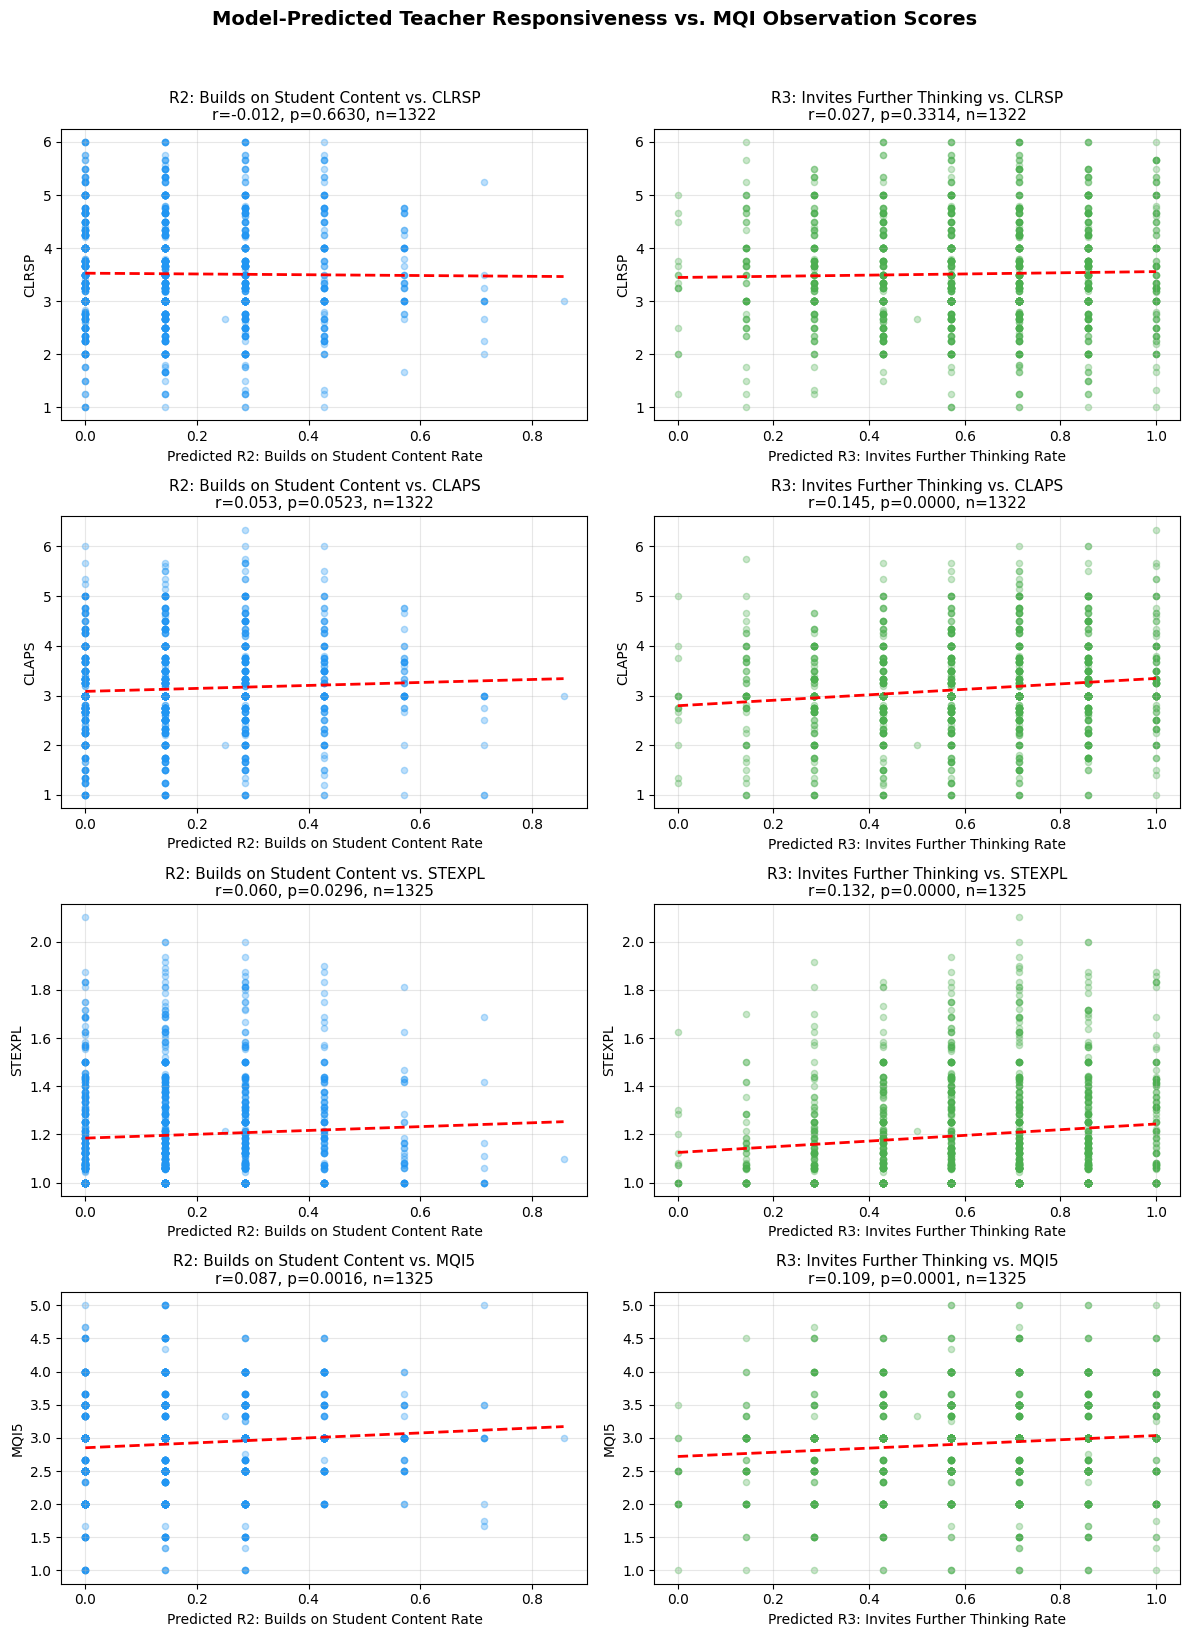

In [41]:
### Descriptive Analysis: Model-Predicted Responsiveness vs. MQI Observation Scores
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ── 1. Load data ──────────────────────────────────────────────────────
inf_df = pd.read_csv('jason_inference_R2_R3.csv')
meta_df = pd.read_csv('NCTE_Transcripts/processed/transcript_metadata.csv', encoding='latin-1')

# Drop junk columns from metadata
meta_df = meta_df[[c for c in meta_df.columns if not c.startswith('Unnamed')]]

print(f"Inference rows: {len(inf_df)}")
print(f"Metadata rows:  {len(meta_df)}")
print(f"Unique OBSIDs in inference: {inf_df['OBSID'].nunique()}")
print(f"Unique OBSIDs in metadata:  {meta_df['OBSID'].nunique()}")

# ── 2. Aggregate predictions by classroom (OBSID) ────────────────────
classroom_preds = inf_df.groupby('OBSID').agg(
    R2_rate=('R2_pred', 'mean'),     # proportion of utterances predicted R2=1
    R3_rate=('R3_pred', 'mean'),     # proportion of utterances predicted R3=1
    n_utterances=('R2_pred', 'count')
).reset_index()

print(f"\nClassrooms with predictions: {len(classroom_preds)}")
print(f"Avg utterances per classroom: {classroom_preds['n_utterances'].mean():.1f}")
print(f"\nR2 rate across classrooms: mean={classroom_preds['R2_rate'].mean():.3f}, "
      f"sd={classroom_preds['R2_rate'].std():.3f}")
print(f"R3 rate across classrooms: mean={classroom_preds['R3_rate'].mean():.3f}, "
      f"sd={classroom_preds['R3_rate'].std():.3f}")

# Fix OBSID type mismatch — force to numeric, drop corrupted rows
classroom_preds['OBSID'] = classroom_preds['OBSID'].astype(int)
meta_df['OBSID'] = pd.to_numeric(meta_df['OBSID'], errors='coerce')
meta_df = meta_df.dropna(subset=['OBSID'])
meta_df['OBSID'] = meta_df['OBSID'].astype(int)

print(f"Metadata rows after cleaning: {len(meta_df)}")

# ── 3. Merge with metadata ───────────────────────────────────────────
merged = classroom_preds.merge(meta_df, on='OBSID', how='inner')
print(f"\nMerged rows: {len(merged)}")

# ── 4. Check which MQI variables are available ───────────────────────
mqi_cols = ['CLRSP', 'CLPC', 'CLNC', 'CLTS', 'CLBM', 'CLPRDT',
            'CLILF', 'CLCU', 'CLAPS', 'CLQF', 'CLINSTD', 'CLSTENG',
            'STEXPL', 'STUCON', 'STUCOM', 'STUENG', 'MQI3', 'MQI5']



for col in mqi_cols:
    if col in merged.columns:
        merged[col] = pd.to_numeric(merged[col], errors='coerce')



available_mqi = [c for c in mqi_cols if c in merged.columns and merged[c].notna().sum() > 30]
print(f"\nAvailable MQI variables ({len(available_mqi)}):")
for col in available_mqi:
    print(f"  {col}: n={merged[col].notna().sum()}, mean={merged[col].mean():.3f}")

# ── 5. Correlations ──────────────────────────────────────────────────
print("\n" + "="*70)
print("CORRELATIONS: Model-Predicted Responsiveness vs. MQI Scores")
print("="*70)

corr_results = []
for mqi_col in available_mqi:
    valid = merged[['R2_rate', 'R3_rate', mqi_col]].dropna()
    if len(valid) < 30:
        continue
    for pred_col, pred_label in [('R2_rate', 'R2 (Builds on student content)'),
                                  ('R3_rate', 'R3 (Invites further thinking)')]:
        r, p_r = pearsonr(valid[pred_col], valid[mqi_col])
        rho, p_rho = spearmanr(valid[pred_col], valid[mqi_col])
        corr_results.append({
            'MQI Variable': mqi_col,
            'Prediction': pred_label,
            'Pearson r': round(r, 3),
            'p (Pearson)': round(p_r, 4),
            'Spearman ρ': round(rho, 3),
            'p (Spearman)': round(p_rho, 4),
            'N': len(valid)
        })

corr_df = pd.DataFrame(corr_results)
print(corr_df.to_string(index=False))
corr_df.to_csv('responsiveness_mqi_correlations.csv', index=False)
print("\nSaved correlations to responsiveness_mqi_correlations.csv")

# ── 6. Figure: Scatterplots for key MQI variables ────────────────────
# Focus on CLRSP (classroom responsiveness) as the primary comparison
# Add a few other theoretically relevant ones if available
plot_cols = [c for c in ['CLRSP', 'CLAPS', 'STEXPL', 'MQI5'] if c in available_mqi]

if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 2, figsize=(12, 4 * len(plot_cols)))
    if len(plot_cols) == 1:
        axes = axes.reshape(1, -1)

    for row, mqi_col in enumerate(plot_cols):
        valid = merged[['R2_rate', 'R3_rate', mqi_col]].dropna()

        for col, (pred_col, pred_label, color) in enumerate([
            ('R2_rate', 'R2: Builds on Student Content', '#2196F3'),
            ('R3_rate', 'R3: Invites Further Thinking', '#4CAF50')
        ]):
            ax = axes[row, col]
            ax.scatter(valid[pred_col], valid[mqi_col], alpha=0.3, s=20, color=color)

            # Add trend line
            z = np.polyfit(valid[pred_col], valid[mqi_col], 1)
            x_line = np.linspace(valid[pred_col].min(), valid[pred_col].max(), 100)
            ax.plot(x_line, np.polyval(z, x_line), color='red', linewidth=2, linestyle='--')

            r, p = pearsonr(valid[pred_col], valid[mqi_col])
            ax.set_xlabel(f'Predicted {pred_label} Rate', fontsize=10)
            ax.set_ylabel(mqi_col, fontsize=10)
            ax.set_title(f'{pred_label} vs. {mqi_col}\nr={r:.3f}, p={p:.4f}, n={len(valid)}', fontsize=11)
            ax.grid(True, alpha=0.3)

    plt.suptitle('Model-Predicted Teacher Responsiveness vs. MQI Observation Scores',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('responsiveness_vs_mqi.png', dpi=200, bbox_inches='tight')
    print("\nSaved figure to responsiveness_vs_mqi.png")
    plt.show()
else:
    print("\n⚠️ No MQI columns found — check metadata column names")

Inference rows: 11611
Metadata rows:  2121
Unique OBSIDs in inference: 1660
Unique OBSIDs in metadata:  2118

Classrooms with predictions: 1660
Avg utterances per classroom: 7.0

R2 rate across classrooms: mean=0.166, sd=0.157
R3 rate across classrooms: mean=0.614, sd=0.235
Metadata rows after cleaning: 1626

Merged rows: 1625

Available observation variables (18):
  CLRSP: n=1322, mean=3.514
  CLPC: n=1322, mean=4.640
  CLNC: n=1322, mean=1.187
  CLTS: n=1322, mean=4.594
  CLBM: n=1322, mean=6.080
  CLPRDT: n=1322, mean=6.345
  CLILF: n=1322, mean=4.426
  CLCU: n=1322, mean=4.311
  CLAPS: n=1322, mean=3.133
  CLQF: n=1322, mean=4.183
  CLINSTD: n=1322, mean=3.929
  CLSTENG: n=1322, mean=5.242
  STEXPL: n=1325, mean=1.198
  STUCON: n=278, mean=1.371
  STUCOM: n=278, mean=2.028
  STUENG: n=278, mean=3.460
  MQI3: n=1047, mean=1.954
  MQI5: n=1325, mean=2.914

CORRELATIONS: Model-Predicted Responsiveness vs. Classroom Observation Scores (CLASS & MQI)
Observation Variable                 

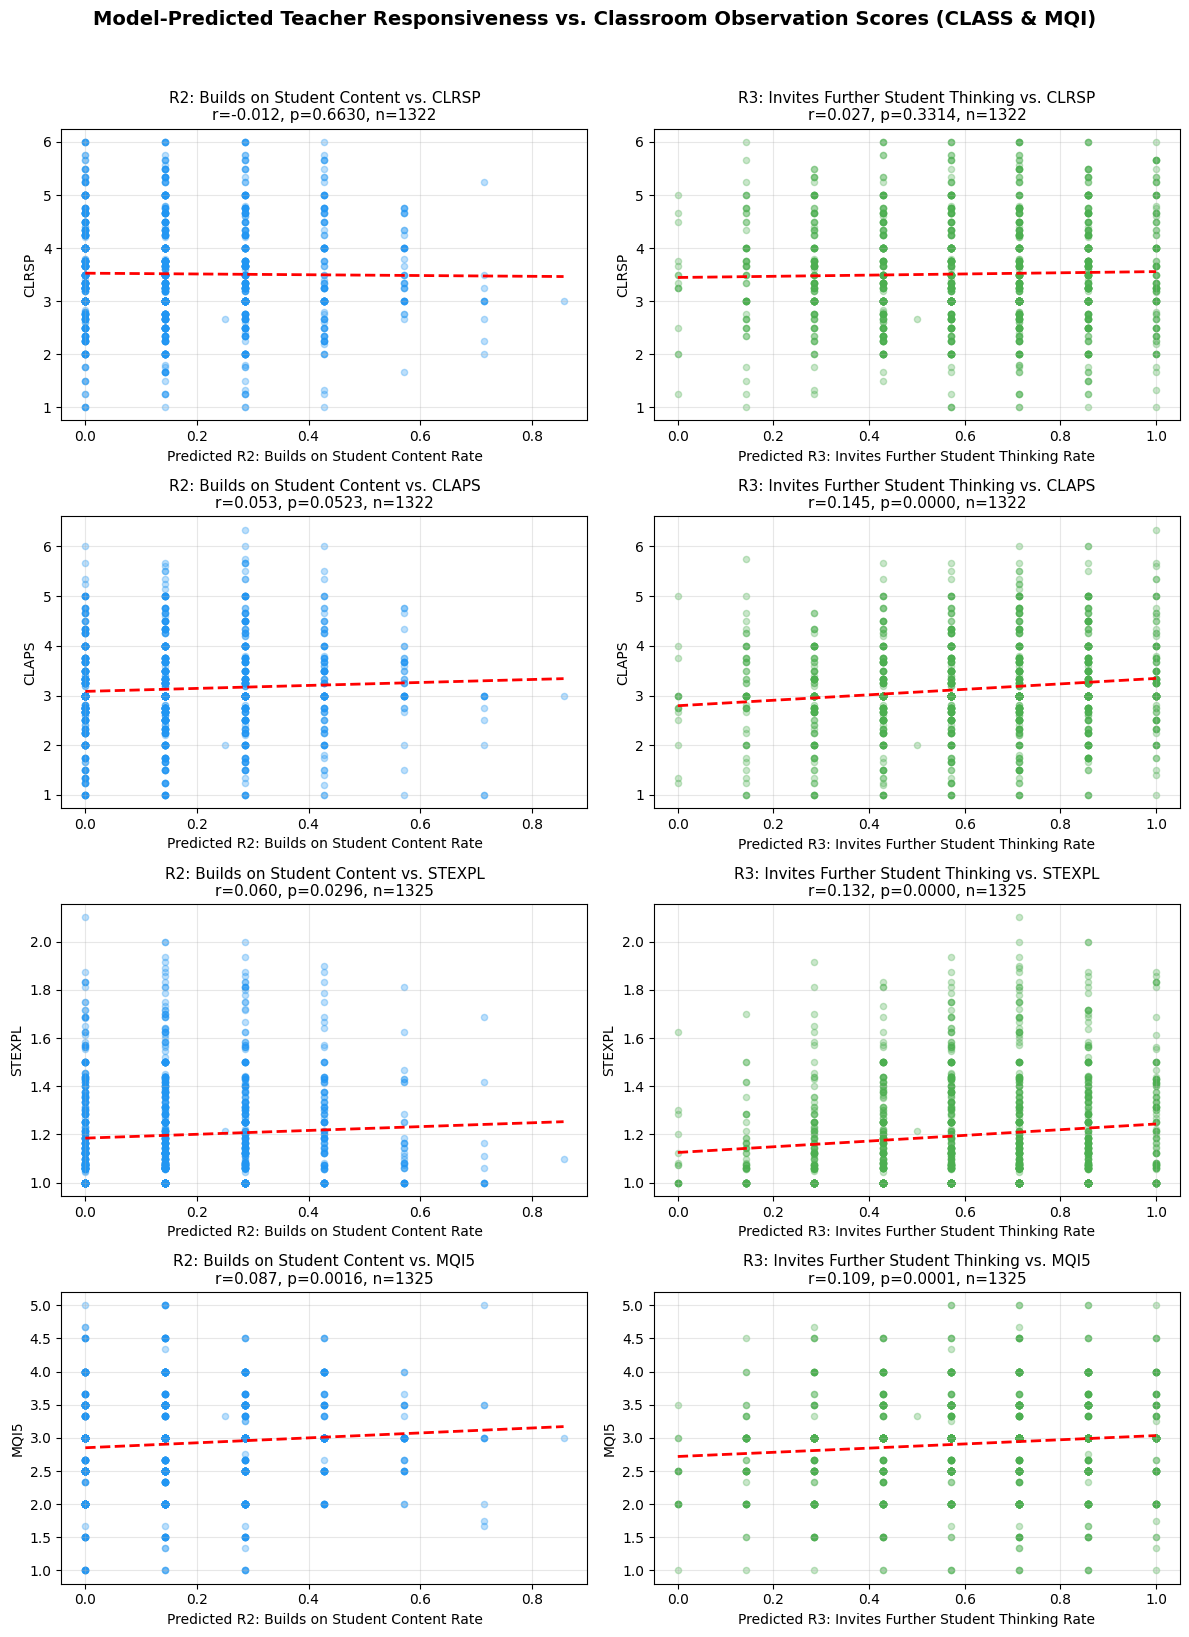

In [42]:
### Descriptive Analysis: Model-Predicted Responsiveness vs. Classroom Observation Scores (CLASS & MQI)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ── 1. Load data ──────────────────────────────────────────────────────
inf_df = pd.read_csv('jason_inference_R2_R3.csv')
meta_df = pd.read_csv('NCTE_Transcripts/processed/transcript_metadata.csv', encoding='latin-1')

# Drop junk columns from metadata
meta_df = meta_df[[c for c in meta_df.columns if not c.startswith('Unnamed')]]

print(f"Inference rows: {len(inf_df)}")
print(f"Metadata rows:  {len(meta_df)}")
print(f"Unique OBSIDs in inference: {inf_df['OBSID'].nunique()}")
print(f"Unique OBSIDs in metadata:  {meta_df['OBSID'].nunique()}")

# ── 2. Aggregate predictions by classroom (OBSID) ────────────────────
classroom_preds = inf_df.groupby('OBSID').agg(
    R2_rate=('R2_pred', 'mean'),     # proportion of utterances predicted R2=1
    R3_rate=('R3_pred', 'mean'),     # proportion of utterances predicted R3=1
    n_utterances=('R2_pred', 'count')
).reset_index()

print(f"\nClassrooms with predictions: {len(classroom_preds)}")
print(f"Avg utterances per classroom: {classroom_preds['n_utterances'].mean():.1f}")
print(f"\nR2 rate across classrooms: mean={classroom_preds['R2_rate'].mean():.3f}, "
      f"sd={classroom_preds['R2_rate'].std():.3f}")
print(f"R3 rate across classrooms: mean={classroom_preds['R3_rate'].mean():.3f}, "
      f"sd={classroom_preds['R3_rate'].std():.3f}")

# Fix OBSID type mismatch — force to numeric, drop corrupted rows
classroom_preds['OBSID'] = classroom_preds['OBSID'].astype(int)
meta_df['OBSID'] = pd.to_numeric(meta_df['OBSID'], errors='coerce')
meta_df = meta_df.dropna(subset=['OBSID'])
meta_df['OBSID'] = meta_df['OBSID'].astype(int)

print(f"Metadata rows after cleaning: {len(meta_df)}")

# ── 3. Merge with metadata ───────────────────────────────────────────
merged = classroom_preds.merge(meta_df, on='OBSID', how='inner')
print(f"\nMerged rows: {len(merged)}")

# ── 4. Check which observation variables are available ───────────────
# CLASS variables: CLRSP (Regard for Student Perspectives), CLPC (Positive Climate),
#   CLNC (Negative Climate), CLTS (Teacher Sensitivity), CLBM (Behavior Management),
#   CLPRDT (Productivity), CLILF (Instructional Learning Formats),
#   CLCU (Content Understanding), CLAPS (Analysis and Inquiry),
#   CLQF (Quality of Feedback), CLINSTD (Instructional Dialogue), CLSTENG (Student Engagement)
# MQI variables: STEXPL (Students Provide Explanations), STUCON, STUCOM, STUENG,
#   MQI3 (Whole-Lesson MQI 3-pt), MQI5 (Whole-Lesson MQI 5-pt)
obs_cols = ['CLRSP', 'CLPC', 'CLNC', 'CLTS', 'CLBM', 'CLPRDT',
            'CLILF', 'CLCU', 'CLAPS', 'CLQF', 'CLINSTD', 'CLSTENG',
            'STEXPL', 'STUCON', 'STUCOM', 'STUENG', 'MQI3', 'MQI5']

for col in obs_cols:
    if col in merged.columns:
        merged[col] = pd.to_numeric(merged[col], errors='coerce')

available_obs = [c for c in obs_cols if c in merged.columns and merged[c].notna().sum() > 30]
print(f"\nAvailable observation variables ({len(available_obs)}):")
for col in available_obs:
    print(f"  {col}: n={merged[col].notna().sum()}, mean={merged[col].mean():.3f}")

# ── 5. Correlations ──────────────────────────────────────────────────
print("\n" + "="*70)
print("CORRELATIONS: Model-Predicted Responsiveness vs. Classroom Observation Scores (CLASS & MQI)")
print("="*70)

corr_results = []
for obs_col in available_obs:
    valid = merged[['R2_rate', 'R3_rate', obs_col]].dropna()
    if len(valid) < 30:
        continue
    for pred_col, pred_label in [('R2_rate', 'R2 (Builds on student content)'),
                                  ('R3_rate', 'R3 (Invites further student thinking)')]:
        r, p_r = pearsonr(valid[pred_col], valid[obs_col])
        rho, p_rho = spearmanr(valid[pred_col], valid[obs_col])
        corr_results.append({
            'Observation Variable': obs_col,
            'Prediction': pred_label,
            'Pearson r': round(r, 3),
            'p (Pearson)': round(p_r, 4),
            'Spearman ρ': round(rho, 3),
            'p (Spearman)': round(p_rho, 4),
            'N': len(valid)
        })

corr_df = pd.DataFrame(corr_results)
print(corr_df.to_string(index=False))
corr_df.to_csv('responsiveness_mqi_correlations.csv', index=False)
print("\nSaved correlations to responsiveness_mqi_correlations.csv")

# ── 6. Figure: Scatterplots for key observation variables ────────────
# CLRSP = CLASS: Regard for Student Perspectives (primary comparison)
# CLAPS = CLASS: Analysis and Inquiry
# STEXPL = MQI: Students Provide Explanations
# MQI5 = MQI: Whole-Lesson MQI, 5-Point Scale
plot_cols = [c for c in ['CLRSP', 'CLAPS', 'STEXPL', 'MQI5'] if c in available_obs]

if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 2, figsize=(12, 4 * len(plot_cols)))
    if len(plot_cols) == 1:
        axes = axes.reshape(1, -1)

    for row, obs_col in enumerate(plot_cols):
        valid = merged[['R2_rate', 'R3_rate', obs_col]].dropna()

        for col, (pred_col, pred_label, color) in enumerate([
            ('R2_rate', 'R2: Builds on Student Content', '#2196F3'),
            ('R3_rate', 'R3: Invites Further Student Thinking', '#4CAF50')
        ]):
            ax = axes[row, col]
            ax.scatter(valid[pred_col], valid[obs_col], alpha=0.3, s=20, color=color)

            # Add trend line
            z = np.polyfit(valid[pred_col], valid[obs_col], 1)
            x_line = np.linspace(valid[pred_col].min(), valid[pred_col].max(), 100)
            ax.plot(x_line, np.polyval(z, x_line), color='red', linewidth=2, linestyle='--')

            r, p = pearsonr(valid[pred_col], valid[obs_col])
            ax.set_xlabel(f'Predicted {pred_label} Rate', fontsize=10)
            ax.set_ylabel(obs_col, fontsize=10)
            ax.set_title(f'{pred_label} vs. {obs_col}\nr={r:.3f}, p={p:.4f}, n={len(valid)}', fontsize=11)
            ax.grid(True, alpha=0.3)

    plt.suptitle('Model-Predicted Teacher Responsiveness vs. Classroom Observation Scores (CLASS & MQI)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('responsiveness_vs_mqi.png', dpi=200, bbox_inches='tight')
    print("\nSaved figure to responsiveness_vs_mqi.png")
    plt.show()
else:
    print("\n⚠️ No observation columns found — check metadata column names")